### Notebook to tweek YAIB's preprocessing of the data, to fit a SSL setup
- This means not having labels but deducting them from the data


#### YAIB preprocessing pipeline flow

raw data -> split data (funciton) -> preprocess data (class)

In this notebook we will be working from the point in the pipeline where the data has already been preprocessed so therefore not the raw data

## Imports

In [1]:
import os
import copy
import logging

import gin
import json
import hashlib
import pandas as pd
import polars as pl
from pathlib import Path
import pickle
from timeit import default_timer as timer
from sklearn.model_selection import StratifiedKFold, KFold, StratifiedShuffleSplit, ShuffleSplit
from icu_benchmarks.data.preprocessor import Preprocessor, PandasClassificationPreprocessor, PolarsClassificationPreprocessor
from icu_benchmarks.constants import RunMode
from icu_benchmarks.run_utils import check_required_keys
from icu_benchmarks.data.constants import DataSplit as Split, DataSegment as Segment, VarType as Var

from icu_benchmarks.data.split_process_data import *
from icu_benchmarks.cross_validation import execute_repeated_cv  # adjust if path is different
from icu_benchmarks.run import *


## Loading in preprocessed data

In [3]:
# Override the outcome scaling range
gin.bind_parameter("base_regression_preprocessor.outcome_min", 0)
gin.bind_parameter("base_regression_preprocessor.outcome_max", 10)

# Call the preprocessing function with the new scale
data = preprocess_data(
    data_dir=Path("demo_data/los/mimic_demo"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression,
)

/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1140: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1145: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1165: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [35]:
print(type(data['train']['FEATURES']))
print(data['train']['FEATURES'].columns)

<class 'polars.dataframe.frame.DataFrame'>
['stay_id', 'time', 'alb', 'alp', 'alt', 'ast', 'be', 'bicar', 'bili', 'bili_dir', 'bnd', 'bun', 'ca', 'cai', 'ck', 'ckmb', 'cl', 'crea', 'crp', 'dbp', 'fgn', 'fio2', 'glu', 'hgb', 'hr', 'inr_pt', 'k', 'lact', 'lymph', 'map', 'mch', 'mchc', 'mcv', 'methb', 'mg', 'na', 'neut', 'o2sat', 'pco2', 'ph', 'phos', 'plt', 'po2', 'ptt', 'resp', 'sbp', 'temp', 'tnt', 'urine', 'wbc', 'MissingIndicator_alb', 'MissingIndicator_alp', 'MissingIndicator_alt', 'MissingIndicator_ast', 'MissingIndicator_be', 'MissingIndicator_bicar', 'MissingIndicator_bili', 'MissingIndicator_bili_dir', 'MissingIndicator_bnd', 'MissingIndicator_bun', 'MissingIndicator_ca', 'MissingIndicator_cai', 'MissingIndicator_ck', 'MissingIndicator_ckmb', 'MissingIndicator_cl', 'MissingIndicator_crea', 'MissingIndicator_crp', 'MissingIndicator_dbp', 'MissingIndicator_fgn', 'MissingIndicator_fio2', 'MissingIndicator_glu', 'MissingIndicator_hgb', 'MissingIndicator_hr', 'MissingIndicator_inr_pt

#### Next step will try to be to build a dataset class that 
1. takes input like the polardataset classes in YAIB
2. computes the output like the MortalityDataset does it for R's repo 
Then we make sure that the raw datastructures can be preprocessed by YAIB's existing tools and that when the preprocessed data is loaded that it can be inputted into R's implementation 

- Maybe be aware of the paired aspect R did in her work. How is class impalance being handled by YAIB? 

This is what Chat says for now, check conversation again when working 

Polars Input
  → group by stay_id
  → sort by time
  → create (T, F) arrays
  → compute masks
  → compute deltas
  → output (data, times, static, label, mask, delta) per patient


## Understanding PredictionPolarsDataset input

In [5]:
## Input, after preprocessing 

# Data dict main structure 
data.keys()
dict_keys(['train', 'val', 'test'])

# Within each split 
data['train'].keys()
dict_keys(['OUTCOME', 'FEATURES'])

# Outcome structure
print(type(data['train']['OUTCOME']))
print(data['train']['OUTCOME'].columns)
<class 'polars.dataframe.frame.DataFrame'>
['stay_id', 'time', 'label']
[num_samples x 3]

# Feature structure 
print(type(data['train']['FEATURES']))
print(data['train']['FEATURES'].columns)
<class 'polars.dataframe.frame.DataFrame'>
['stay_id', 'time', 'alb', 'alp', 'alt', 'ast', 'be', 'bicar', 'bili', 'bili_dir', 'bnd', 'bun', 'ca', 'cai', 'ck', 'ckmb', 'cl', 'crea', 'crp', 'dbp', 'fgn', 'fio2', 'glu', 'hgb', 'hr', 'inr_pt', 'k', 'lact', 'lymph', 'map', 'mch', 'mchc', 'mcv', 'methb', 'mg', 'na', 'neut', 'o2sat', 'pco2', 'ph', 'phos', 'plt', 'po2', 'ptt', 'resp', 'sbp', 'temp', 'tnt', 'urine', 'wbc', 'MissingIndicator_alb', 'MissingIndicator_alp', 'MissingIndicator_alt', 'MissingIndicator_ast', 'MissingIndicator_be', 'MissingIndicator_bicar', 'MissingIndicator_bili', 'MissingIndicator_bili_dir', 'MissingIndicator_bnd', 'MissingIndicator_bun', 'MissingIndicator_ca', 'MissingIndicator_cai', 'MissingIndicator_ck', 'MissingIndicator_ckmb', 'MissingIndicator_cl', 'MissingIndicator_crea', 'MissingIndicator_crp', 'MissingIndicator_dbp', 'MissingIndicator_fgn', 'MissingIndicator_fio2', 'MissingIndicator_glu', 'MissingIndicator_hgb', 'MissingIndicator_hr', 'MissingIndicator_inr_pt', 'MissingIndicator_k', 'MissingIndicator_lact', 'MissingIndicator_lymph', 'MissingIndicator_map', 'MissingIndicator_mch', 'MissingIndicator_mchc', 'MissingIndicator_mcv', 'MissingIndicator_methb', 'MissingIndicator_mg', 'MissingIndicator_na', 'MissingIndicator_neut', 'MissingIndicator_o2sat', 'MissingIndicator_pco2', 'MissingIndicator_ph', 'MissingIndicator_phos', 'MissingIndicator_plt', 'MissingIndicator_po2', 'MissingIndicator_ptt', 'MissingIndicator_resp', 'MissingIndicator_sbp', 'MissingIndicator_temp', 'MissingIndicator_tnt', 'MissingIndicator_urine', 'MissingIndicator_wbc']
[num_samples x 98]

SyntaxError: invalid syntax (4206911709.py, line 14)

In [23]:
data['train']['FEATURES'].columns

['stay_id',
 'time',
 'alb',
 'alp',
 'alt',
 'ast',
 'be',
 'bicar',
 'bili',
 'bili_dir',
 'bnd',
 'bun',
 'ca',
 'cai',
 'ck',
 'ckmb',
 'cl',
 'crea',
 'crp',
 'dbp',
 'fgn',
 'fio2',
 'glu',
 'hgb',
 'hr',
 'inr_pt',
 'k',
 'lact',
 'lymph',
 'map',
 'mch',
 'mchc',
 'mcv',
 'methb',
 'mg',
 'na',
 'neut',
 'o2sat',
 'pco2',
 'ph',
 'phos',
 'plt',
 'po2',
 'ptt',
 'resp',
 'sbp',
 'temp',
 'tnt',
 'urine',
 'wbc',
 'MissingIndicator_alb',
 'MissingIndicator_alp',
 'MissingIndicator_alt',
 'MissingIndicator_ast',
 'MissingIndicator_be',
 'MissingIndicator_bicar',
 'MissingIndicator_bili',
 'MissingIndicator_bili_dir',
 'MissingIndicator_bnd',
 'MissingIndicator_bun',
 'MissingIndicator_ca',
 'MissingIndicator_cai',
 'MissingIndicator_ck',
 'MissingIndicator_ckmb',
 'MissingIndicator_cl',
 'MissingIndicator_crea',
 'MissingIndicator_crp',
 'MissingIndicator_dbp',
 'MissingIndicator_fgn',
 'MissingIndicator_fio2',
 'MissingIndicator_glu',
 'MissingIndicator_hgb',
 'MissingIndicator_

In [24]:
i = 'height'
k = True
data['train']['FEATURES'].filter(pl.col(f'MissingIndicator_{i}')==k)[[f'MissingIndicator_{i}', f'{i}']]

MissingIndicator_height,height
bool,f64
true,0.0
true,0.0
true,0.0
true,0.0
true,0.0
…,…
true,0.0
true,0.0
true,0.0


In [25]:
data['train']['FEATURES'].filter(pl.col('MissingIndicator_sex')==True)[['sex', 'MissingIndicator_sex']]

sex,MissingIndicator_sex
i64,bool


In [26]:
data['train']['FEATURES'].filter(pl.col('stay_id') == 201006).sort('time')

stay_id,time,alb,alp,alt,ast,be,bicar,bili,bili_dir,bnd,bun,ca,cai,ck,ckmb,cl,crea,crp,dbp,fgn,fio2,glu,hgb,hr,inr_pt,k,lact,lymph,map,mch,mchc,mcv,methb,mg,na,neut,…,MissingIndicator_fio2,MissingIndicator_glu,MissingIndicator_hgb,MissingIndicator_hr,MissingIndicator_inr_pt,MissingIndicator_k,MissingIndicator_lact,MissingIndicator_lymph,MissingIndicator_map,MissingIndicator_mch,MissingIndicator_mchc,MissingIndicator_mcv,MissingIndicator_methb,MissingIndicator_mg,MissingIndicator_na,MissingIndicator_neut,MissingIndicator_o2sat,MissingIndicator_pco2,MissingIndicator_ph,MissingIndicator_phos,MissingIndicator_plt,MissingIndicator_po2,MissingIndicator_ptt,MissingIndicator_resp,MissingIndicator_sbp,MissingIndicator_temp,MissingIndicator_tnt,MissingIndicator_urine,MissingIndicator_wbc,age,sex,height,weight,MissingIndicator_age,MissingIndicator_sex,MissingIndicator_height,MissingIndicator_weight
i64,duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,i64,f64,f64,bool,bool,bool,bool
201006,0ms,-0.60284,0.0,0.0,0.0,0.0,-0.338794,0.0,0.0,-0.671308,-0.640933,-0.865833,0.0,0.0,0.0,-0.69228,-0.488212,0.0,0.516011,0.0,0.0,0.454634,-0.930323,0.681749,-0.580126,-0.658271,0.0,-0.61205,0.422837,-0.763181,-0.987222,-0.101033,0.0,-0.750164,-1.599037,0.737334,…,true,false,false,false,false,false,true,false,false,false,false,false,true,false,false,false,false,true,true,false,false,true,false,false,false,true,true,true,false,-0.16248,1,-0.943257,-0.888026,false,false,false,false
201006,1h,-0.60284,0.0,0.0,0.0,0.0,-0.338794,0.0,0.0,-0.671308,-0.640933,-0.865833,0.0,0.0,0.0,-0.69228,-0.488212,0.0,0.619331,0.0,0.0,0.454634,-0.930323,0.925322,-0.580126,-0.658271,0.0,-0.61205,0.735582,-0.763181,-0.987222,-0.101033,0.0,-0.750164,-1.599037,0.737334,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,false,true,-0.16248,1,-0.943257,-0.888026,false,false,false,false
201006,2h,-0.60284,0.0,0.0,0.0,0.0,-0.338794,0.0,0.0,-0.671308,-0.640933,-0.865833,0.0,0.0,0.0,-0.69228,-0.488212,0.0,0.791532,0.0,0.0,0.454634,-0.930323,0.925322,-0.580126,-0.658271,0.0,-0.61205,0.90813,-0.763181,-0.987222,-0.101033,0.0,-0.750164,-1.599037,0.737334,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,false,true,-0.16248,1,-0.943257,-0.888026,false,false,false,false
201006,3h,-0.60284,0.0,0.0,0.0,0.0,-0.338794,0.0,0.0,-0.671308,-0.640933,-0.865833,0.0,0.0,0.0,-0.69228,-0.488212,0.0,0.860412,0.0,0.0,0.454634,-0.930323,0.844131,-0.580126,-0.658271,0.0,-0.61205,1.199306,-0.763181,-0.987222,-0.101033,0.0,-0.750164,-1.599037,0.737334,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,false,true,true,true,-0.16248,1,-0.943257,-0.888026,false,false,false,false
201006,4h,-0.60284,0.0,0.0,0.0,0.0,-0.338794,0.0,0.0,-0.671308,-0.640933,-0.865833,0.0,0.0,0.0,-0.69228,-0.488212,0.0,0.17161,0.0,0.0,0.454634,-0.930323,0.140477,-0.580126,-0.658271,0.0,-0.61205,0.034602,-0.763181,-0.987222,-0.101033,0.0,-0.750164,-1.599037,0.737334,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,true,true,-0.16248,1,-0.943257,-0.888026,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
201006,6d 20h,-0.60284,0.0,0.0,0.0,-1.290317,0.221696,0.0,0.0,-0.041957,1.679445,1.03133,2.202911,0.0,0.0,-0.69228,1.108013,0.0,1.067052,0.0,2.424732,-0.639334,0.761649,1.331277,-0.580126,2.467983,-0.758467,-1.038713,

## Understanding PredictionPolarsDataset output 

In [43]:
from icu_benchmarks.data.loader import PredictionPolarsDataset, CommonPolarsDataset
from torch.utils.data import DataLoader

dataset_class = PredictionPolarsDataset
#dataset_class = CommonPolarsDataset

batch_size=1

train_dataset = dataset_class(data, split=Split.train, ram_cache=False)
train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
    )

# Get one batch from the DataLoader
for batch_idx, (data, labels, pad_mask) in enumerate(train_loader):
    # Print the data and other details of the batch
    print(f"Batch {batch_idx + 1}:")
    print("Data (tensor):", data)

    # Break after the first batch to just inspect one batch
    break

['stay_id', 'alb', 'alp', 'alt', 'ast', 'be', 'bicar', 'bili', 'bili_dir', 'bnd', 'bun', 'ca', 'cai', 'ck', 'ckmb', 'cl', 'crea', 'crp', 'dbp', 'fgn', 'fio2', 'glu', 'hgb', 'hr', 'inr_pt', 'k', 'lact', 'lymph', 'map', 'mch', 'mchc', 'mcv', 'methb', 'mg', 'na', 'neut', 'o2sat', 'pco2', 'ph', 'phos', 'plt', 'po2', 'ptt', 'resp', 'sbp', 'temp', 'tnt', 'urine', 'wbc', 'MissingIndicator_alb', 'MissingIndicator_alp', 'MissingIndicator_alt', 'MissingIndicator_ast', 'MissingIndicator_be', 'MissingIndicator_bicar', 'MissingIndicator_bili', 'MissingIndicator_bili_dir', 'MissingIndicator_bnd', 'MissingIndicator_bun', 'MissingIndicator_ca', 'MissingIndicator_cai', 'MissingIndicator_ck', 'MissingIndicator_ckmb', 'MissingIndicator_cl', 'MissingIndicator_crea', 'MissingIndicator_crp', 'MissingIndicator_dbp', 'MissingIndicator_fgn', 'MissingIndicator_fio2', 'MissingIndicator_glu', 'MissingIndicator_hgb', 'MissingIndicator_hr', 'MissingIndicator_inr_pt', 'MissingIndicator_k', 'MissingIndicator_lact', '

In [11]:
# Get one batch from the DataLoader
for batch_idx, (data, labels, pad_mask) in enumerate(train_loader):
    # Print the data and other details of the batch
    print(f"Batch {batch_idx + 1}:")
    print("Data (tensor):", data)
    print("Labels (tensor):", labels)
    print("Padding Mask (tensor):", pad_mask)
    
    # Optionally, inspect the shape of the batch tensors
    print(f"Data shape: {data.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Padding Mask shape: {pad_mask.shape}")
    
    # Break after the first batch to just inspect one batch
    break


['stay_id', 'alb', 'alp', 'alt', 'ast', 'be', 'bicar', 'bili', 'bili_dir', 'bnd', 'bun', 'ca', 'cai', 'ck', 'ckmb', 'cl', 'crea', 'crp', 'dbp', 'fgn', 'fio2', 'glu', 'hgb', 'hr', 'inr_pt', 'k', 'lact', 'lymph', 'map', 'mch', 'mchc', 'mcv', 'methb', 'mg', 'na', 'neut', 'o2sat', 'pco2', 'ph', 'phos', 'plt', 'po2', 'ptt', 'resp', 'sbp', 'temp', 'tnt', 'urine', 'wbc', 'MissingIndicator_alb', 'MissingIndicator_alp', 'MissingIndicator_alt', 'MissingIndicator_ast', 'MissingIndicator_be', 'MissingIndicator_bicar', 'MissingIndicator_bili', 'MissingIndicator_bili_dir', 'MissingIndicator_bnd', 'MissingIndicator_bun', 'MissingIndicator_ca', 'MissingIndicator_cai', 'MissingIndicator_ck', 'MissingIndicator_ckmb', 'MissingIndicator_cl', 'MissingIndicator_crea', 'MissingIndicator_crp', 'MissingIndicator_dbp', 'MissingIndicator_fgn', 'MissingIndicator_fio2', 'MissingIndicator_glu', 'MissingIndicator_hgb', 'MissingIndicator_hr', 'MissingIndicator_inr_pt', 'MissingIndicator_k', 'MissingIndicator_lact', '

#### Mortality Dataset output

In [ ]:
# I need to create all of these 6 from the preprocessed data format above 

Dynamic Features 
[batch_size, num_sensors, num_timesteps]

Static Features
[batch_size, num_static_features]

label_array
[batch_size, 1]

Sensor Mask
[batch_size, num_sensors, num_timesteps]

Time Features
[batch_size, num_timesteps]

Delta Features
[batch_size, num_sensors, num_timesteps]

## BAT dataset class

In [2]:
# Loads in preprocessed from YAIB into a data structure that can be ingested by R's repo and thereby models 
import torch
import numpy as np
import polars as pl
from torch.utils.data import Dataset
from typing import Dict, Tuple
from icu_benchmarks.data.loader import CommonPolarsDataset
from torch.utils.data import DataLoader
from icu_benchmarks.constants import RunMode
from torch.nn.functional import pad

class BATPolarsDataset(CommonPolarsDataset):
    """Subclass of common dataset for prediction tasks.

    Args:
        ram_cache (bool, optional): Whether the complete dataset should be stored in ram. Defaults to True.
    """

    def __init__(self, *args, ram_cache: bool = True, runmode=None, **kwargs):
        #super().__init__(*args, **kwargs)
        #self.outcome_df = self.grouping_df
        #self.ram_cache(ram_cache)

        # TEMP BEFORE GIN SETUP AND UPLOAD OF CLASS IN LOADER.PY 
        # Explicitly pass the vars_dict to the parent class (CommonPolarsDataset)
        self.vars = vars_dict  # Define vars_dict manually
        # Pass all arguments to the parent class, including 'vars'
        super().__init__(vars=self.vars, **kwargs)
        self.outcome_df = self.grouping_df
        self.ram_cache(ram_cache)
        self.runmode = runmode
    

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Function to sample from the data split of choice. Used for deep learning implementations.

        Args:
            idx: A specific row index to sample.

        Returns:
            A sample from the data, consisting of data, labels, padding mask, and other arrays.
        """
        if self._cached_dataset is not None:
            return self._cached_dataset[idx]

        # UNCOMMENT FOR NORMALIZATION OF TIME For normalizing times array (has not been done in preprocessing) 
        #global_max_time_ms = (
        #self.features_df.select(pl.col(self.vars["SEQUENCE"]).max()).item().total_seconds() * 1000  # Convert to milliseconds
        #)
        
        # Extracting the stay_id for the specific index
        stay_id = self.outcome_df[self.vars["GROUP"]].unique()[idx]  

        # Selecting label column 
        label = self.outcome_df.filter(pl.col(self.vars["GROUP"]) == stay_id)[self.vars["LABEL"]].to_numpy()
        
        # Select dynamic values (excluding stay_id and time columns)
        dynamic_columns = self.vars["DYNAMIC"]  # Use DYNAMIC columns defined in gin
        data = self.features_df.filter(pl.col(self.vars["GROUP"]) == stay_id).select(dynamic_columns).to_numpy()
        
        # Select missingness indicators for dynamic features (matching the same order as the dynamic features)
        missingness_columns = [f'MissingIndicator_{col}' for col in dynamic_columns]
        mask = self.features_df.filter(pl.col(self.vars["GROUP"]) == stay_id).select(missingness_columns).to_numpy()
        mask = (1 - mask)

        # Select static features (assuming they are labeled 'age', 'sex', etc. in the dataset)
        static_columns = self.vars["STATIC"]  # Use STATIC columns defined in gin
        static = self.features_df.filter(pl.col(self.vars["GROUP"]) == stay_id).select(static_columns)[0].to_numpy().flatten()

        # Select timeseries 
        time_column = self.vars["SEQUENCE"]
        times_raw = self.features_df.filter(pl.col(self.vars["GROUP"]) == stay_id).select(time_column).to_numpy().flatten()
        # tmp solution for times normalization, should be done in preprocessing. See how R did it 
        times_numeric = (times_raw - times_raw[0]).astype('timedelta64[ms]').astype(np.float32)
        # NO NORNALIZATION: Convert milliseconds to minutes
        times = times_numeric / 60000  # 1 minute = 60,000 ms
        # NORMALIZATION: to [-1, 1] based on global max in milliseconds
        #times = (times_numeric / global_max_time_ms) * 2 - 1

        # Array containing delta time values 
        delta = self.get_delta_t(times, data, mask) 

        # Permute 
        data = data.T
        mask = mask.T
        delta = delta.T
    
        # Return all of the required arrays as tensors
        return (
            torch.from_numpy(data),
            torch.from_numpy(mask),
            torch.from_numpy(label),
            torch.from_numpy(times),
            torch.from_numpy(static),
            torch.from_numpy(delta)
            )
    
    @staticmethod
    def get_delta_t(times, measurements, measurement_indicators):
        """
        From R's repo 
        Creates array with time difference from the most recent feature measurement.
        """
        dt_list = []

        # First observation has delta t = 0
        first_dt = np.zeros(measurement_indicators.shape[1:], dtype=np.float32)  # (F,)
        dt_list.append(first_dt)

        last_dt = first_dt.copy()  # Initialize last_dt before the loop
        for i in range(1, measurement_indicators.shape[0]):
            # Calculate time difference only for observed values
            last_dt = np.where(
                measurement_indicators[i - 1],  # If the previous value was observed
                np.full_like(last_dt, times[i] - times[i - 1]),  # Compute time difference
                times[i] - times[i - 1] + last_dt,  # If the previous value was missing, propagate the last valid time difference
            )
            dt_list.append(last_dt)

        dt_array = np.stack(dt_list)  # Combine the list of deltas into a single array
        dt_array = dt_array.astype(np.float32)  # Ensure consistent data type
        dt_array.shape = measurements.shape  # Reshape to match measurements
        dt_array = dt_array * ~(measurement_indicators.astype(bool))  # Mask the missing values

        return dt_array

   
    def collate_fn_pad_to_longest_in_batch(self):
        def collate_fn(batch):
            data, mask, label, times, static, delta = zip(*batch)
            max_len = max(x.shape[-1] for x in data)
            original_lengths = [x.shape[-1] for x in data]
            
            def pad_2d_tensor(tensor, max_len):
                pad_amt = max_len - tensor.shape[-1]
                return pad(tensor, (0, pad_amt)) if pad_amt > 0 else tensor
            
            def pad_1d_tensor(tensor, max_len):
                pad_amt = max_len - tensor.shape[0]
                return pad(tensor, (0, pad_amt)) if pad_amt > 0 else tensor

            data   = torch.stack([pad_2d_tensor(x, max_len) for x in data])
            mask   = torch.stack([pad_2d_tensor(x, max_len) for x in mask])
            delta  = torch.stack([pad_2d_tensor(x, max_len) for x in delta])
            times  = torch.stack([pad_1d_tensor(x, max_len) for x in times])
            static = torch.stack(static)

            # In a regression setting there is one label per time bin 
            if self.runmode == RunMode.regression:
                label = torch.stack([pad_1d_tensor(x, max_len) for x in label])
            # In a classification setting there is one label per patient/stay_id 
            else:
                label = torch.stack(label).squeeze()   

            obs_mask = torch.zeros((len(data), max_len), dtype=torch.int32)
            for i, seq_len in enumerate(original_lengths):
                obs_mask[i, :seq_len] = 1
            
            return data, mask, label, times, static, delta, obs_mask

        return collate_fn
    
    def __len__(self) -> int:
        """
        Return the total number of samples in the dataset.
        """
        return self.outcome_df[self.vars["GROUP"]].n_unique()
    


In [52]:
vars_dict = {
    "GROUP": "stay_id",
    "SEQUENCE": "time",
    "LABEL": "label",
    "DYNAMIC": ["alb", "alp", "alt", "ast", "be", "bicar", "bili", "bili_dir", "bnd", "bun", "ca", "cai", "ck", "ckmb", "cl",
        "crea", "crp", "dbp", "fgn", "fio2", "glu", "hgb", "hr", "inr_pt", "k", "lact", "lymph", "map", "mch", "mchc", "mcv",
        "methb", "mg", "na", "neut", "o2sat", "pco2", "ph", "phos", "plt", "po2", "ptt", "resp", "sbp", "temp", "tnt", "urine",
        "wbc"],
    "STATIC": ["age", "sex", "height", "weight"],
}

In [57]:
# Load the gin config
gin.parse_config_file("/work3/s185395/YAIB/configs/tasks/Regression.gin")

# Call the preprocessing function with the new scale
data = preprocess_data(
    data_dir=Path("demo_data/los/mimic_demo"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression,
)

/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1140: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1145: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1165: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [53]:
# Load the gin config
gin.parse_config_file("/work3/s185395/YAIB/configs/tasks/BinaryClassification.gin")

# Call the preprocessing function with the new scale
data = preprocess_data(
    data_dir=Path("/work3/s185395/YAIB/demo_data/mortality24/mimic_demo"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.classification
)


/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1140: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1145: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1165: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [58]:
ids = []
for i in range(len(data['test']['FEATURES']['stay_id'].unique())):
    ids.append(data['test']['FEATURES']['stay_id'].unique()[i])

lengths = []
for i in range(len(ids)):
    lengths.append(len(data['test']['FEATURES'].filter(pl.col('stay_id') == ids[i])['time']))
   
lengths

[46,
 16,
 69,
 169,
 31,
 32,
 86,
 50,
 114,
 27,
 32,
 42,
 169,
 123,
 24,
 169,
 22,
 91,
 24,
 119,
 47,
 169,
 59,
 32,
 62,
 15,
 26]

In [6]:
# Initialize your dataset class
dataset_class = BATPolarsDataset

# Initialize dataset instance
train_dataset = dataset_class(data=data, split="test", ram_cache=False, runmode = RunMode.regression)
#train_dataset = dataset_class(data=data, split="test", ram_cache=False, runmode = RunMode.classification)

# Create a DataLoader
batch_size = 3  # Adjust batch size as needed
train_loader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=train_dataset.collate_fn_pad_to_longest_in_batch())

# Step 2: Inspect one batch from the DataLoader

# Get one batch from the DataLoader
for batch_idx, (data, mask, labels, times ,static, delta, obs_mask) in enumerate(train_loader):
    #print(f"Batch {batch_idx + 1}:")
    print("Data (tensor):", data.shape)
    print("Data Mask (tensor):", mask.shape) 
    print("Labels (tensor):", labels.shape)
    print("Times (tensor):", times.shape)
    print("Static (tensor):", static.shape)
    print("Delta (tensor):", delta.shape)
    print("Observation mask (tensor):", obs_mask.shape)
    
    # Break after the first batch to inspect one batch
    break

Data (tensor): torch.Size([3, 48, 69])
Data Mask (tensor): torch.Size([3, 48, 69])
Labels (tensor): torch.Size([3, 69])
Times (tensor): torch.Size([3, 69])
Static (tensor): torch.Size([3, 4])
Delta (tensor): torch.Size([3, 48, 69])
Observation mask (tensor): torch.Size([3, 69])


/tmp/ipykernel_1720622/2654998761.py:95: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  torch.from_numpy(label),


## SSL dataset class (inherits from BAT dataset)

In [43]:
import torch
import random
import numpy as np

class SSLPolarsDataset(BATPolarsDataset):
    def __init__(self, *args, max_obs=24, forecast_horizon=2, **kwargs):
        """
        SSL dataset that slices each batch into observation and forecasting windows.

        Args:
            max_obs (int): Length of the observation window in time bins (e.g., 24 = 24h).
            forecast_horizon (int): Length of the forecasting window in time bins (e.g., 2 = 2h).
        """
        super().__init__(*args, **kwargs)
        self.max_obs = max_obs
        self.forecast_horizon = forecast_horizon

    def collate_fn_ssl_windows(self):
        base_collate = super().collate_fn_pad_to_longest_in_batch()

        def collate_fn(batch):
            data, mask, label, times, static, delta, obs_mask = base_collate(batch)
            B, C, T = data.shape

            t1_ix = None
            tries = 0
            max_tries = B  # Retry up to one attempt per patient in the batch

            while t1_ix is None and tries < max_tries:
                patient_idx = random.randint(0, B - 1)
                patient_mask = obs_mask[patient_idx].bool()
                valid_indices = torch.where(patient_mask)[0]

                # Enforce: minimum 12 time bins of history and room for forecast
                valid_indices = valid_indices[valid_indices >= 12]
                valid_indices = valid_indices[valid_indices <= valid_indices[-1] - self.forecast_horizon]

                if len(valid_indices) > 0:
                    t1_ix = int(np.random.choice(valid_indices.cpu().numpy()))
                    break

                tries += 1

            if t1_ix is None:
                raise ValueError("No valid t1 index found in batch after retrying.")

            t0_ix = max(0, t1_ix - self.max_obs)
            t2_ix = t1_ix + self.forecast_horizon

            # Slice all patients at same window
            obs_data = data[:, :, t0_ix:t1_ix]
            obs_mask_out = mask[:, :, t0_ix:t1_ix]
            obs_times = times[:, t0_ix:t1_ix]
            obs_delta = delta[:, :, t0_ix:t1_ix]

            forecast_target = data[:, :, t1_ix:t2_ix]
            forecast_mask = mask[:, :, t1_ix:t2_ix]

            return {
                    'obs_data': obs_data,
                    'obs_mask': obs_mask_out,
                    'obs_times': obs_times,
                    'obs_delta': obs_delta,
                    'forecast_target': forecast_target,
                    'forecast_mask': forecast_mask,
                    'static': static,
                    #'debug': {  # UNCOMMENT FOR DEBUGGING
                    #    't0_ix': t0_ix,
                    #    't1_ix': t1_ix,
                    #    't2_ix': t2_ix
                    #    }
                    }
        return collate_fn


In [ ]:
# Load the gin config
gin.parse_config_file("/work3/s185395/YAIB/configs/tasks/Regression.gin")

# Call the preprocessing function with the new scale
data = preprocess_data(
    data_dir=Path("demo_data/los/mimic_demo"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression,
)

In [68]:
# Initialize your dataset class
dataset_class = SSLPolarsDataset

# Initialize dataset instance
ssl_dataset = dataset_class(data=data, split="test", ram_cache=False, runmode=RunMode.regression)

# Create a DataLoader using the SSL-specific collate function
batch_size = 3
ssl_loader = DataLoader(ssl_dataset, batch_size=batch_size, collate_fn=ssl_dataset.collate_fn_ssl_windows())

# Inspect one batch from the DataLoader
for batch_idx, batch in enumerate(ssl_loader):
    print("obs_data (tensor):", batch['obs_data'].shape)
    print("obs_mask (tensor):", batch['obs_mask'].shape)
    print("obs_times (tensor):", batch['obs_times'].shape)
    print("obs_delta (tensor):", batch['obs_delta'].shape)
    print("forecast_target (tensor):", batch['forecast_target'].shape)
    print("forecast_mask (tensor):", batch['forecast_mask'].shape)
    print("static (tensor):", batch['static'].shape)

    # Optional: print first observation mask
    print("First obs_mask row:", batch['obs_mask'][0])

    break  # Stop after first batch


obs_data (tensor): torch.Size([3, 48, 13])
obs_mask (tensor): torch.Size([3, 48, 13])
obs_times (tensor): torch.Size([3, 13])
obs_delta (tensor): torch.Size([3, 48, 13])
forecast_target (tensor): torch.Size([3, 48, 2])
forecast_mask (tensor): torch.Size([3, 48, 2])
static (tensor): torch.Size([3, 4])
First obs_mask row: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [16]:
p = 0
for i in range(len(batch['obs_data'][p,:,0])):
    if not torch.all(batch['forecast_mask'][p,i,:] == 0):
        print(i)
        print('Observation window')
        print(batch['obs_data'][p,i,:])
        print(batch['obs_mask'][p,i,:])
        #print(batch['obs_delta'][p,i,:])
        print('\nForecasting window')
        print(batch['forecast_target'][p,i,:])
        print(batch['forecast_mask'][p,i,:])


17
Observation window
tensor([-0.3106, -0.3106, -1.0682, -0.1728, -0.0695, -0.7238, -0.7238, -0.5172,
        -0.4483, -0.7927,  0.5160, -0.3106, -1.0682, -0.9305, -1.1371,  0.6538,
        -0.6550, -1.2060, -0.8616, -0.9994, -0.2417,  0.0338, -1.2749, -0.8616],
       dtype=torch.float64)
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Forecasting window
tensor([-1.0682, -0.6550], dtype=torch.float64)
tensor([1, 1])
22
Observation window
tensor([-1.1586, -0.9962, -0.8338, -1.1045, -0.6985, -0.4549, -0.6714, -0.4008,
        -0.7797, -0.8879, -1.2668, -1.2127, -1.3751, -1.5375, -1.4833, -1.1586,
        -1.0503, -0.8338, -1.1045, -0.8609, -1.0503, -0.8879, -1.1586, -1.4833],
       dtype=torch.float64)
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Forecasting window
tensor([-1.5916, -1.5916], dtype=torch.float64)
tensor([1, 1])
27
Observation window
tensor([ 0.0993, -0.3536, -1.3242,  0.3581,  0.1964, -0.8713, -1.065

## Testing the BAT and SSL PolarDataset classes

In [75]:
# Initialize datasets
bat_dataset = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode = RunMode.regression)
ssl_dataset = SSLPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.regression)

# Get a sample batch
base_batch = next(iter(DataLoader(bat_dataset, batch_size=10, collate_fn=bat_dataset.collate_fn_pad_to_longest_in_batch())))
ssl_batch = next(iter(DataLoader(ssl_dataset, batch_size=10, collate_fn=ssl_dataset.collate_fn_ssl_windows())))


In [76]:
# Compare base batch (BAT) to SSL slices

# Slicing times 
t0 = ssl_batch['debug']['t0_ix']
t1 = ssl_batch['debug']['t1_ix']
t2 = ssl_batch['debug']['t2_ix']

# Observation window
if torch.allclose(ssl_batch['obs_data'][0], base_batch[0][0, :, t0:t1]):
    print("✅ obs_data matches original observation window.")
else:
    print("❌ obs_data does NOT match.")

# Observation mask
if torch.allclose(ssl_batch['obs_mask'][0], base_batch[1][0, :, t0:t1]):
    print("✅ obs_mask matches original observation window mask.")
else:
    print("❌ obs_mask does NOT match.")

# Forecasting window
if torch.allclose(ssl_batch['forecast_target'][0], base_batch[0][0, :, t1:t2]):
    print("✅ forecast_target matches original forecasting window.")
else:
    print("❌ forecast_target does NOT match.")

# Forecasting mask
if torch.allclose(ssl_batch['forecast_mask'][0], base_batch[1][0, :, t1:t2]):
    print("✅ forecast_mask matches original forecasting window mask.")
else:
    print("❌ forecast_mask does NOT match.")

# Times for observation window
if torch.allclose(ssl_batch['obs_times'][0], base_batch[3][0, t0:t1]):
    print("✅ obs_times match original times in observation window.")
else:
    print("❌ obs_times do NOT match.")

# Delta between times in observation window
if torch.allclose(ssl_batch['obs_delta'][0], base_batch[5][0, :, t0:t1]):
    print("✅ obs_delta matches original deltas in observation window.")
else:
    print("❌ obs_delta does NOT match.")

# Static features
if torch.allclose(ssl_batch['static'][0], base_batch[4][0, :]):
    print("✅ static features match.")
else:
    print("❌ static features do NOT match.")

✅ obs_data matches original observation window.
✅ obs_mask matches original observation window mask.
✅ forecast_target matches original forecasting window.
✅ forecast_mask matches original forecasting window mask.
✅ obs_times match original times in observation window.
✅ obs_delta matches original deltas in observation window.
✅ static features match.


## Try single forward pass of BATPolarsDataset output data into R's BAT model
- Be aware that venvs might be different and some fixed have to be found there 

### R's model and predction heads

In [97]:
# Head classes

import torch.nn as nn

class BinaryClassificationHead(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

class ForecastingHead(nn.Module):
    def __init__(self, input_dim, forecast_len, sensors_count):
        super().__init__()
        self.linear = nn.Linear(input_dim, sensors_count * forecast_len)
        self.sensors_count = sensors_count
        self.forecast_len = forecast_len

    def forward(self, x):
        out = self.linear(x)
        return out.reshape(-1, self.sensors_count, self.forecast_len)



In [98]:
import torch
import numpy as np
from torch import nn
from x_transformers import Encoder


def masked_mean_pooling(datatensor, mask):
    """
    Adapted from HuggingFace's Sentence Transformers:
    https://github.com/UKPLab/sentence-transformers/
    Calculate masked average for final dimension of tensor
    TO DO: expand to multiple dimensions
    """
    if mask == None:
        averaged = torch.mean(datatensor, dim=2)
        averaged = torch.mean(averaged, dim=1)

    else:
        # eliminate all values learned from nonexistant timepoints
        mask_expanded = mask.unsqueeze(-1).expand(datatensor.size()).float()
        data_summed = torch.sum(datatensor * mask_expanded, dim=1)

        # find out number of existing timepoints
        data_counts = mask_expanded.sum(1)
        data_counts = torch.clamp(data_counts, min=1e-9)  # put on min clamp

        # Calculate average:
        averaged = data_summed / (data_counts)

    return averaged


def masked_max_pooling(datatensor, mask):
    """
    Adapted from HuggingFace's Sentence Transformers:
    https://github.com/UKPLab/sentence-transformers/
    Calculate masked average for final dimension of tensor
    """

    if mask == None:
        maxed_1 = torch.max(datatensor, dim=2, keepdim=False)[0]
        maxed_2 = torch.max(maxed_1, dim=1, keepdim=False)[0]  # (N, 18)

    else:
        # eliminate all values learned from missing timepoints
        mask_expanded = mask.unsqueeze(-1).expand(datatensor.size()).float() # (N, F, T) --> (N, F, T, 18)

        datatensor[mask_expanded == 0] = (
            -1e9
        )  # Set padding tokens to large negative value
        maxed_1 = torch.max(datatensor, 2)[0]
        maxed_2 = torch.max(maxed_1, 1)[0]

    return maxed_2


class PositionalEncodingTF(nn.Module):
    """
    Based on the SEFT positional encoding implementation
    """

    def __init__(self, d_model, max_len=500):
        super(PositionalEncodingTF, self).__init__()
        self.max_len = max_len
        self.d_model = d_model
        self._num_timescales = d_model // 2

    def getPE(self, P_time):
        B = P_time.shape[1]

        P_time = P_time.float()

        # create a timescale of all times from 0-1
        timescales = self.max_len ** np.linspace(0, 1, self._num_timescales)

        # make a tensor to hold the time embeddings
        times = torch.Tensor(P_time.cpu()).unsqueeze(2)

        # scale the timepoints according to the 0-1 scale
        scaled_time = times / torch.Tensor(timescales[None, None, :])
        # Use a 32-D embedding to represent a single time point
        pe = torch.cat(
            [torch.sin(scaled_time), torch.cos(scaled_time)], axis=-1
        )  # T x B x d_model
        pe = pe.type(torch.FloatTensor)

        return pe

    def forward(self, P_time):
        pe = self.getPE(P_time)
        # pe = pe.cuda()
        return pe


class EncoderClassifierCrossParallel(nn.Module):

    def __init__(
        self,
        device="cpu",
        pooling="mean",
        num_classes=2,
        sensors_count=37,
        max_timepoint_count=215,
        static_count=8,
        value_embed_size=8,
        layers=1,
        heads=1,
        dropout=0.2,
        attn_dropout=0.2,
        return_intermediates=False,
        use_mask=False,
        use_static=True,
        obs_strategy="both",
        **kwargs
    ):
        super().__init__()

        self.return_intermediates = return_intermediates
        self.obs_strategy = obs_strategy
        self.pooling = pooling
        self.device = device
        self.use_mask = use_mask
        self.sensors_count = sensors_count
        self.max_timepoint_count = max_timepoint_count
        self.static_count = static_count

        if self.obs_strategy in ("indicator_only", "obs_only"):  # BINARY
            # print("binary_values_only")
            self.sensor_axis_dim = self.sensors_count  # BINARY
            self.time_axis_dim = self.max_timepoint_count  # BINARY
        else:  # BINARY
            self.sensor_axis_dim = 2 * self.sensors_count  # BINARY
            self.time_axis_dim = min(2 * self.max_timepoint_count, 100)  # BINARY

        self.static_out = self.static_count + 4
        self.embed_out = value_embed_size
        self.sensor_encoding_out = min(600, round(1.6 * sensors_count**0.50))
        if self.sensor_encoding_out % 2 != 0:
            self.sensor_encoding_out += 1
        
        self.attn_layers_1 = Encoder(
            dim=self.sensor_encoding_out + self.embed_out,  # new
            depth=layers,
            heads=heads,
            attn_dropout=attn_dropout,
            ff_dropout=dropout,
            attn_flash=True,

        )

        self.attn_layers_2 = Encoder(
            dim=self.sensor_encoding_out + self.embed_out,
            depth=layers,
            heads=heads,
            attn_dropout=attn_dropout,
            ff_dropout=dropout,
            attn_flash=True,
        )

        self.sensor_encoding = torch.nn.Embedding(
            sensors_count, self.sensor_encoding_out
        )
        if self.obs_strategy in ("indicator_only", "obs_only"):  # BINARY
            self.time_embedding = nn.Linear(1, self.embed_out)  # 2 because of mask only
        else:
            self.time_embedding = nn.Linear(
                2, self.embed_out
            )  # 2 because of sensor reading + mask

        self.use_static = use_static

        self.nonlinear_merger_1 = nn.Linear(
            2 * (self.sensor_encoding_out + self.embed_out),
            2 * (self.sensor_encoding_out + self.embed_out),
        )
        
        if self.use_static:
            print("use static")
            self.static_embedding = nn.Linear(self.static_count, self.static_out)

            self.nonlinear_merger_2 = nn.Linear(
                2 * (self.sensor_encoding_out + self.embed_out) + self.static_out,
                2 * (self.sensor_encoding_out + self.embed_out) + self.static_out,
            )

        self.pos_encoder = PositionalEncodingTF(
            self.sensor_encoding_out + self.embed_out
        )  

        # create layers necessary for pooling fxn
        if self.pooling == "conv":
             # taken from metnet
            self.sensor_conv_first = nn.Conv1d(
                self.max_timepoint_count, 1, kernel_size=(1,)
            )  # taken from metnet
            self.time_conv_second = nn.Conv1d(
                self.sensors_count, 1, kernel_size=(1,)
            )
        if self.pooling == "linear_unroll":
            self.sensor_linear_first = nn.Linear(
                self.sensors_count * self.time_axis_dim, self.time_axis_dim
            )
            self.time_linear_second = nn.Linear(
                self.sensor_axis_dim * self.max_timepoint_count, self.sensor_axis_dim
            )
        if self.pooling == "parameterised_mean":
            self.linear_layer_sensor = nn.Linear(self.time_axis_dim, 1)
            self.linear_layer_time = nn.Linear(self.sensor_axis_dim, 1)

    def forward(self, x, static, time, sensor_mask, **kwargs):

        # QUESTION: should my embedding output size be min(600, round(1.6 * dim ** 0.50))?
        # QUESTION: why does LR keep going down despite val loss doing well?  

        x_time = torch.clone(x).unsqueeze(3)  # (N, F, T, E) 

        """
        x = x.permute((0, 2, 1)) (N, T, F)
        sensor_mask = sensor_mask.permute((0, 2, 1))
        mask = sensor_mask.sum(-1)
        valid_time_points = mask.any(dim=0)
        x = x[:, valid_timepoints, :].permute((0, 2, 1))
        time = time[:, valid_timepoints]
        sensor_mask = sensor_mask[:, valid_time_points, :].permute((0,2,1)) 

        x_time = torch.clone(x).unsqueeze(3)  # (N, F, T, E) 

        print(f"Reduced batch size by {torch.count_nonzero(valid_time_points)} timepoints")
        """

        # add indication for missing values to data
        x_time_mask = torch.clone(sensor_mask).unsqueeze(3)  # (N, F, T, E)
        if self.obs_strategy == "indicator_only":  # Binary
            x_time = x_time_mask.float()
        elif self.obs_strategy == "obs_only":
            x_time = x_time
        elif self.obs_strategy == "both":
            x_time = torch.cat([x_time, x_time_mask], axis=3)  # (N, F, T, 2E)
        else:
            raise NotImplementedError(f"Obs strategy {self.obs_strategy} not found.")

        # make embeddings
        x_time = self.time_embedding(x_time)  # (N, F, T, 8E)

        # Free memory from unused tensors
        del x_time_mask

        # make "encodings" for each sensor
        s_list = torch.arange(0, self.sensors_count)
        sensor_encoding = x.clone()  # make new version for embedding
        sensor_encoding = torch.permute(sensor_encoding, (0, 2, 1))  # (N, T, F)
        sensor_encoding[:, :, :] = (
            s_list  # for every batch/timepoint, we have spots for embedding sensors
        )

        sensor_encoding = self.sensor_encoding(
            sensor_encoding.long()
        )  # create sensor embedding/encoding/something (N, T, F, 10)
        sensor_encoding = torch.permute(sensor_encoding, (0, 2, 1, 3))  # (N, F, T, 10)
        x_time = torch.cat(
            (x_time, sensor_encoding), dim=3
        )  # (N, F, T, 18E) where 1 holds the sensor value

        # Free memory from unused tensor
        del sensor_encoding

        with torch.no_grad():
            # add positional encodings
            pe = self.pos_encoder(time).to(self.device)  # taken from RAINDROP (N, T, pe)
            pe = pe.unsqueeze(2)  # CHECK IF THIS IS RIGHT
            # Repeat the 2nd dimension 36 times
            pe = pe.repeat(1, 1, self.sensors_count, 1)
            pe = torch.permute(pe, (0, 2, 1, 3))  # (N, F, T, 18) 
        
        x_time = torch.add(x_time, pe)  # (N, F, T, 18E)
        del pe

        # get versions/shapes ready for attention
        n, f, t, e = x_time.shape
        # make copy for other attention
        x_sensor = x_time.clone()
        x_sensor = torch.permute(x_sensor, (0, 2, 1, 3))  # (N, T, F, 18)
        x_time = x_time.view(n * f, t, e)  # (N*F, T, 18)
        x_sensor = x_sensor.reshape(n * t, f, e)  # (N*T, F, 18)

        # make mask of all empty (missing) timepoints
        timepoint_mask = torch.clone(x)  # (N, F, T)
        timepoint_mask = torch.permute(timepoint_mask, (0, 2, 1))  # (N, T, F)
        mask = (
            torch.count_nonzero(timepoint_mask, dim=2)
        ) > 0  # mask for sum of all sensors for each person/at each timepoint (N, T)
        mask = mask.repeat(self.sensors_count, 1)  # (N*F, T)
        if not self.use_mask:
            mask_attention = None
        else:
            mask_attention = mask
        
        del x # Free memory from unused tensor
        del timepoint_mask

        # run sensor attention
        if self.return_intermediates:
            x_sensor, sensor_intermediates = self.attn_layers_1(
                x_sensor, return_hiddens=True
            )
        else:
            x_sensor = self.attn_layers_1(x_sensor)
        x_sensor = x_sensor.reshape(n, t, f, e)  # (N, T, F, 18)

        # run time attention
        if self.return_intermediates:
            x_time, time_intermediates = self.attn_layers_2(
                x_time, mask=mask_attention, return_hiddens=True
            )  # attention on time
        else:
            x_time = self.attn_layers_2(x_time, mask=mask_attention)
        x_time = x_time.reshape(n, f, t, e)  # (N, F, T, 18)
        mask = mask.reshape(n, f, t)  # (N, F, T)

        cross = True

        if cross:
            # cross and perform attention again
            x_time = torch.permute(x_time, (0, 2, 1, 3))  # (N, T, F, 18)
            x_time = x_time.reshape(n * t, f, e)  # (N*T, F, 18) flatten
            if self.return_intermediates:
                x_time, time_intermediates = self.attn_layers_1(
                    x_time, return_hiddens=True
                )
            else:
                x_time = self.attn_layers_1(x_time)
            x_time = x_time.view(n, t, f, e)  # (N, T, F, 18)
            x_time = torch.permute(x_time, (0, 2, 1, 3))  # (N, F, T, 18) is this needed?

            x_sensor = torch.permute(x_sensor, (0, 2, 1, 3))  # (N, F, T, 18)
            x_sensor = x_sensor.reshape(n * f, t, e)  # (N*F, T, 18) flatten
            # mask = mask.reshape(n*f, t) # (N*F, T)
            if self.return_intermediates:
                x_sensor, sensor_intermediates = self.attn_layers_2(
                    x_sensor, mask=mask_attention, return_hiddens=True
                )  # attention on time
            else:
                x_sensor = self.attn_layers_2(x_sensor, mask=mask_attention)
            # mask = mask.reshape(n, f, t) # (N, F, T)
            x_sensor = x_sensor.view(n, f, t, e)  # (N, F, T, 18)
            #x_sensor = torch.permute(x_sensor, (0, 2, 1, 3))  # (N, T, F, 18) is this needed?

        del mask_attention

        # Pool
        if not self.use_mask:
            mask_pooling = None
        else:
            mask_pooling = mask

        if self.pooling == "mean":
            #x_sensor = torch.mean(x_sensor, dim=2)
            #x_sensor = torch.mean(x_sensor, dim=1)
            x_sensor = masked_mean_pooling(x_sensor, mask_pooling)
            x_time = masked_mean_pooling(x_time, mask_pooling)
        elif self.pooling == "median":
            x_sensor = torch.median(x_sensor, dim=1)[0]
            x_time = torch.median(x_time, dim=1)[0]
        elif self.pooling == "sum":
            x_sensor = torch.sum(x_sensor, dim=1)  # sum on sensors
            x_time = torch.sum(x_time, dim=1)  # sum on time
        elif self.pooling == "max":
            #x_sensor = torch.max(x_sensor, dim=2, keepdim=False)[0]
            #x_sensor = torch.max(x_sensor, dim=1, keepdim=False)[0]  # (N, 18)
            x_sensor = masked_max_pooling(x_sensor, mask_pooling)
            x_time = masked_max_pooling(x_time, mask_pooling)
        elif self.pooling == "linear_unroll":
            x_sensor = x_sensor.reshape(x_sensor.shape[0], -1)
            x_sensor = self.sensor_linear_first(x_sensor)
            x_time = x_time.reshape(x_time.shape[0], -1)
            x_time = self.time_linear_second(x_time)
        elif self.pooling == "parameterised_mean":
            sensor_weights = self.linear_layer_sensor(x_sensor)
            time_weight = self.linear_layer_time(x_time)
            x_sensor = (x_sensor @ sensor_weights) / sensor_weights.sum().squeeze()
            x_time = (x_time @ time_weight) / time_weight.sum().squeeze()
        elif self.pooling == "conv":
            x_sensor = self.time_conv_second(x_sensor).squeeze()
            x_time = self.sensor_conv_first(x_time).squeeze()

        # concatenate poolingated attented tensors
        x_merged = torch.cat((x_sensor, x_time), dim=1)  # (N, F+T)
        x_merged = self.nonlinear_merger_1(x_merged).relu()

        if self.use_static:
            static = self.static_embedding(static)  # .relu()
            x_merged = torch.cat((x_merged, static), axis=1)
            nonlinear_merged = self.nonlinear_merger_2(x_merged).relu()
        else:
            nonlinear_merged = x_merged

        if self.return_intermediates:
            return (
                sensor_intermediates.attn_intermediates[0].post_softmax_attn,
                time_intermediates.attn_intermediates[0].post_softmax_attn,
            )
       
        return nonlinear_merged



In [ ]:
class EncoderPrediction(nn.Module):
    def __init__(self, encoder_class, prediction_head, prediction_head_kwargs=None):
        super().__init__()
        self.encoder_class = encoder_class
        self.prediction_head = prediction_head
        self.prediction_head_kwargs = prediction_head_kwargs or {}
        self.head = None  # Instantiated lazily

    def forward(self, x, static, time, sensor_mask):
        features = self.encoder_class(x, static, time, sensor_mask)

        # Lazily instantiate the head based on input dim 
        if self.head is None:
            self.head = self.prediction_head(
                input_dim=features.shape[1], 
                **self.prediction_head_kwargs
                ).to(features.device)

        return self.head(features)


### Load data

In [101]:
# Load in classification data, as R is doing binary classification tasks

vars_dict = {
    "GROUP": "stay_id",
    "SEQUENCE": "time",
    "LABEL": "label",
    "DYNAMIC": ["alb", "alp", "alt", "ast", "be", "bicar", "bili", "bili_dir", "bnd", "bun", "ca", "cai", "ck", "ckmb", "cl",
        "crea", "crp", "dbp", "fgn", "fio2", "glu", "hgb", "hr", "inr_pt", "k", "lact", "lymph", "map", "mch", "mchc", "mcv",
        "methb", "mg", "na", "neut", "o2sat", "pco2", "ph", "phos", "plt", "po2", "ptt", "resp", "sbp", "temp", "tnt", "urine",
        "wbc"],
    "STATIC": ["age", "sex", "height", "weight"],
}

# Load the gin config
gin.parse_config_file("/work3/s185395/YAIB/configs/tasks/BinaryClassification.gin")

# Call the preprocessing function with the new scale
data = preprocess_data(
    #data_dir=Path("/work3/s185395/YAIB/demo_data/mortality24/mimic_demo"),
    data_dir=Path("/work3/s185395/YAIB-cohorts/data/mortality24/mimic"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.classification
)


In [ ]:
ids = []
for i in range(len(data['test']['FEATURES']['stay_id'].unique())):
    ids.append(data['test']['FEATURES']['stay_id'].unique()[i])

lengths = []
for i in range(len(ids)):
    lengths.append(len(data['test']['FEATURES'].filter(pl.col('stay_id') == ids[i])['time']))
   
lengths

### Passing one BATPolarsDataset batch through R's model + Binary classification head

In [16]:
import torch
from torch.utils.data import DataLoader

# === Load a batch from BATPolarsDataset ===
bat_dataset = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)
bat_loader = DataLoader(
    bat_dataset,
    batch_size=8,
    collate_fn=bat_dataset.collate_fn_pad_to_longest_in_batch()
)
batch = next(iter(bat_loader))

# === Prepare batch tensors ===
x = batch[0].float()         # (B, F, T)
sensor_mask = batch[1]       # (B, F, T)
label = batch[2]             # (B,)
time = batch[3].float()      # (B, T)
static = batch[4].float()    # (B, S)

# === Create encoder ===
encoder = EncoderClassifierCrossParallel(
    device='cpu',
    pooling='max',
    value_embed_size=128,
    layers=1,
    heads=2,
    dropout=0.1,
    attn_dropout=0.4,
    use_mask=False,
    sensors_count=x.shape[1],
    max_timepoint_count=x.shape[2],
    static_count=static.shape[1]
)

# === Instantiate wrapper model ===
model = EncoderPrediction(
    encoder_class=encoder,
    prediction_head=BinaryClassificationHead, 
    prediction_head_kwargs={"num_classes": 2}
    
)

# === Run forward ===
with torch.no_grad():
    logits = model(x, static, time, sensor_mask)

probs = torch.softmax(logits, dim=1)
preds = torch.argmax(probs, dim=1)

# === Output ===
print("Logits:", logits)
print("Probs:", probs)
print("Predictions:", preds)
print("True labels:", label)


use static


/appl9/python/3.10.16/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Logits: tensor([[-0.0246,  0.1326],
        [-0.0442,  0.0703],
        [-0.0332,  0.1099],
        [ 0.0051,  0.1497],
        [-0.0486,  0.1220],
        [-0.0494,  0.1603],
        [-0.0500,  0.0818],
        [-0.0495,  0.1684]])
Probs: tensor([[0.4608, 0.5392],
        [0.4714, 0.5286],
        [0.4643, 0.5357],
        [0.4639, 0.5361],
        [0.4574, 0.5426],
        [0.4478, 0.5522],
        [0.4671, 0.5329],
        [0.4457, 0.5543]])
Predictions: tensor([1, 1, 1, 1, 1, 1, 1, 1])
True labels: tensor([1, 0, 0, 0, 0, 1, 0, 0], dtype=torch.int32)


### Setting up simple supervised training

In [22]:
# funciton to reset parameters everytime i run the nb cell so that it does not continue training from the previous model (loss starts where last models loss finished)
def reset_model_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()
        elif hasattr(layer, 'children'):
            reset_model_weights(layer)  # recursively reset nested layers


In [27]:
# Training setup
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Progress bar for Jupyter
from torchmetrics.classification import BinaryAUROC


# === Hyperparameters ===
epochs = 3
batch_size = 64
lr = 0.0001
val_interval = 1  # Validate every x epochs

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# === Dataset and DataLoaders ===
train_dataset = BATPolarsDataset(data=data, split="train", ram_cache=False, runmode=RunMode.classification)
val_dataset   = BATPolarsDataset(data=data, split="val", ram_cache=False, runmode=RunMode.classification)

train_loader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=train_dataset.collate_fn_pad_to_longest_in_batch())
val_loader   = DataLoader(val_dataset, batch_size=batch_size, collate_fn=val_dataset.collate_fn_pad_to_longest_in_batch())

# === Encoder model ===
encoder = EncoderClassifierCrossParallel(
    device=device, 
    pooling='max',
    value_embed_size=128,
    layers=1,
    heads=2,
    dropout=0.1,
    attn_dropout=0.4,
    use_mask=False,
    sensors_count=train_dataset[0][0].shape[0],
    max_timepoint_count=train_dataset[0][0].shape[1],
    static_count=train_dataset[0][4].shape[0],
).to(device)

# === Full model with prediction head ===
model = EncoderPrediction(
    encoder_class=encoder,
    prediction_head=BinaryClassificationHead,
    prediction_head_kwargs={'num_classes': 2}
).to(device)

reset_model_weights(model)

# === Loss and Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# === Track losses ===
train_losses = []
val_losses = []
val_aurocs = []

# === Training Loop ===
for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    for batch in train_iter:
        x, mask, label, times, static, delta, obs_mask = batch
        x = x.to(device).float()
        mask = mask.to(device)
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        output = model(x, static=static, time=times, sensor_mask=mask)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_iter.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # === Conditional Validation ===
    if (epoch + 1) % val_interval == 0 or epoch == epochs - 1:
        model.eval()
        auroc_metric = BinaryAUROC().to(device)
        total_val_loss = 0.0

        val_iter = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]", leave=False)
        with torch.no_grad():
            for batch in val_iter:
                x, mask, label, times, static, delta, obs_mask = batch
                x = x.to(device).float()
                mask = mask.to(device)
                times = times.to(device).float()
                static = static.to(device).float()
                label = label.to(device).long()

                output = model(x, static=static, time=times, sensor_mask=mask)
                
                # Update AUROC
                probs = torch.softmax(output, dim=1)
                auroc_metric.update(probs[:, 1], label.int())  # Prob of class 1

                # Compute loss 
                loss = criterion(output, label)
                total_val_loss += loss.item()
                val_iter.set_postfix(val_loss=loss.item())

        epoch_auroc = auroc_metric.compute().item()
        val_aurocs.append(epoch_auroc)

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | AUROC: {epoch_auroc:.4f}")
    else:
        val_losses.append(None)
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f}")

# === Plot training and validation loss and validation AUCROC ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Plot Loss ===
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(
    [i for i, v in enumerate(val_losses) if v is not None],
    [v for v in val_losses if v is not None],
    label='Val Loss',
    marker='x'
)
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# === Plot AUROC ===
axes[1].plot(
    [e for e in range(1, epochs + 1) if (e % val_interval == 0 or e == epochs)],
    val_aurocs,
    label='Val AUROC',
    marker='^'
)
axes[1].set_title("Validation AUROC per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUROC")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


use static


Epoch 1 [Train]:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.2776 | Val Loss: 0.2492 | AUROC: 0.7746


Epoch 2 [Train]:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch 2 [Val]:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.2477 | Val Loss: 0.2276 | AUROC: 0.8246


Epoch 3 [Train]:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch 3 [Val]:   0%|          | 0/96 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [28]:
from torchmetrics.classification import BinaryAUROC
from tqdm import tqdm

# === Prepare test dataset and dataloader ===
test_dataset = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)
test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=test_dataset.collate_fn_pad_to_longest_in_batch())

# === Torchmetrics AUROC
auroc_metric = BinaryAUROC().to(device)

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on test set"):
        x, mask, label, times, static, delta, obs_mask = batch
        x = x.to(device).float()
        mask = mask.to(device)
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        logits = model(x, static=static, time=times, sensor_mask=mask)
        probs = torch.softmax(logits, dim=1)[:, 1]  # prob for class 1
        auroc_metric.update(probs, label)

# === Final AUROC
test_auroc = auroc_metric.compute()
print(f"\n✅ Final Test AUROC: {test_auroc:.4f}")



Evaluating on test set:   0%|                                                                                               | 0/120 [00:00<?, ?it/s]

Evaluating on test set: 100%|█████████████████████████████████████████████████████████████████████████████████████| 120/120 [01:13<00:00,  1.62it/s]


✅ Final Test AUROC: 0.8123


### Passing one SSLPolarsDataset batch through R's model

In [29]:
from torch.utils.data import DataLoader

# === Load SSL dataset for testing ===
ssl_dataset = SSLPolarsDataset(data=data, split="train", ram_cache=False, runmode=RunMode.classification)
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=2,  # keep it small for testing
    collate_fn=ssl_dataset.collate_fn_ssl_windows()
)

# === Get one batch ===
batch = next(iter(ssl_loader))

# === Prepare inputs ===
x = batch['obs_data'].float()
mask = batch['obs_mask']
times = batch['obs_times'].float()
static = batch['static'].float()
target = batch['forecast_target'].float()  # For shape comparison
forecast_len = target.shape[2]

# === Instantiate encoder + forecasting head model ===
encoder = EncoderClassifierCrossParallel(
    device='cpu',
    pooling='max',
    value_embed_size=128,
    layers=1,
    heads=2,
    dropout=0.1,
    attn_dropout=0.4,
    use_mask=True,
    sensors_count=x.shape[1],
    max_timepoint_count=x.shape[2],
    static_count=static.shape[1]
)

model = EncoderPrediction(
    encoder_class=encoder,
    prediction_head=ForecastingHead,
    prediction_head_kwargs={"sensors_count": x.shape[1], "forecast_len": forecast_len}
)

# === Forward pass ===
with torch.no_grad():
    output = model(x, static, times, mask)

print("Forecast output shape:", output.shape)  # should match target shape
print("Target shape:", target.shape)


use static
Forecast output shape: torch.Size([2, 48, 2])
Target shape: torch.Size([2, 48, 2])


In [9]:
# 1. Create the SSL dataset
ssl_dataset = SSLPolarsDataset(
    data=data, 
    split="train", 
    ram_cache=False, 
    runmode=RunMode.classification
    )

# 2. Create a DataLoader with the SSL collate_fn
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=2,
    collate_fn=ssl_dataset.collate_fn_ssl_windows()
)

# 3. Get one SSL batch
ssl_batch = next(iter(ssl_loader))

# 4. Inspect shapes (optional)
for k, v in ssl_batch.items():
    print(f"{k}: {v.shape}")

# 5. Move tensors to device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = ssl_batch['obs_data'].to(device).float()          # (B, F, T_obs)
mask = ssl_batch['obs_mask'].to(device)               # (B, F, T_obs)
times = ssl_batch['obs_times'].to(device).float()     # (B, T_obs)
static = ssl_batch['static'].to(device).float()       # (B, S)

# 6. Create the model
model = EncoderClassifierCrossParallel(
    device=device,
    pooling='max',
    value_embed_size=128,
    layers=1,
    heads=2,
    dropout=0.1,
    attn_dropout=0.4,
    use_mask=False,
    sensors_count=ssl_batch['obs_data'].shape[1],
    max_timepoint_count=ssl_batch['obs_data'].shape[2],
    static_count=ssl_batch['static'].shape[1],
    num_classes=2,  # for testing; can be 1 if you adapt for SSL
).to(device)

# 7. Run forward pass
output = model(x, static=static, time=times, sensor_mask=mask)

print("Model output shape:", output.shape)

obs_data: torch.Size([2, 48, 18])
obs_mask: torch.Size([2, 48, 18])
obs_times: torch.Size([2, 18])
obs_delta: torch.Size([2, 48, 18])
forecast_target: torch.Size([2, 48, 2])
forecast_mask: torch.Size([2, 48, 2])
static: torch.Size([2, 4])
use static
Model output shape: torch.Size([2, 2])


### Setting up simple self-supervised training

use static


[Train] Epoch 1:   0%|                                                                                                      | 0/382 [00:00<?, ?it/s]/appl9/python/3.10.16/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
[Train] Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 382/382 [04:16<00:00,  1.49it/s]


Epoch 1 | Train Loss: 0.798122 | Skipped Batches: 0/382


[Val] Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 96/96 [00:58<00:00,  1.63it/s]


Epoch 1 | Val Loss: 0.617624 | MAE: 0.555879 | Skipped Batches: 0/96


...

Epoch 2 | Val Loss: 0.569243 | MAE: 0.526997 | Skipped Batches: 0/96


[Train] Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 382/382 [04:09<00:00,  1.53it/s]


Epoch 3 | Train Loss: 0.555425 | Skipped Batches: 0/382


[Val] Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 96/96 [00:57<00:00,  1.66it/s]


Epoch 3 | Val Loss: 0.546061 | MAE: 0.502644 | Skipped Batches: 0/96


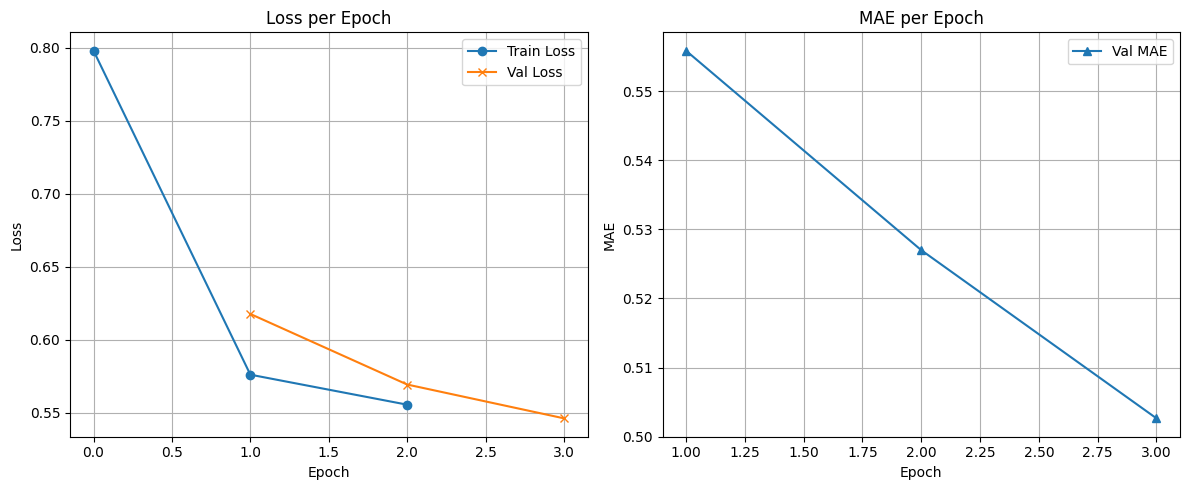

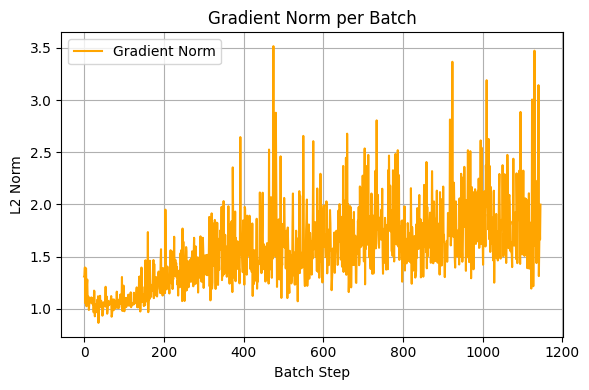

In [102]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchmetrics.regression import MeanAbsoluteError


# === Hyperparameters ===
epochs = 3
batch_size = 64
lr = 1e-4
validate_every = 1  # 🔥 Run validation every N epochs

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# === Datasets & Loaders ===
ssl_train = SSLPolarsDataset(data=data, split="train", ram_cache=False, runmode=RunMode.classification)
ssl_val   = SSLPolarsDataset(data=data, split="val",   ram_cache=False, runmode=RunMode.classification)

train_loader = DataLoader(ssl_train, batch_size=batch_size, collate_fn=ssl_train.collate_fn_ssl_windows())
val_loader   = DataLoader(ssl_val,   batch_size=batch_size, collate_fn=ssl_val.collate_fn_ssl_windows())

sample_batch = next(iter(train_loader))

# === Extract shapes from the batch ===
obs_sample = sample_batch['obs_data']         # [1, F, T_obs]
static_sample = sample_batch['static']             # [1, S]
forecast_sample = sample_batch['forecast_target']  # [1, F, T_forecast]

encoder = EncoderClassifierCrossParallel(
    device=device,
    pooling='max',
    value_embed_size=128,
    layers=1,
    heads=2,
    dropout=0.1,
    attn_dropout=0.4,
    use_mask=True,
    sensors_count=obs_sample.shape[1],
    max_timepoint_count=obs_sample.shape[2],
    static_count=static_sample.shape[1]
).to(device)

model = EncoderPrediction(
    encoder_class=encoder,
    prediction_head=ForecastingHead,
    prediction_head_kwargs={
        'sensors_count': forecast_sample.shape[1],
        'forecast_len': forecast_sample.shape[2]
    }
).to(device)


mae_metric = MeanAbsoluteError().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# === Track losses
train_losses = []
val_losses = []
val_maes = []
grad_norms = []  # 🔥 Track gradient norms

# === Training Loop
for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    skipped_batches = 0
    total_batches = 0

    for batch in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}"):
        total_batches += 1

        # Move batch to device
        x = batch['obs_data'].to(device).float()
        mask = batch['obs_mask'].to(device)
        times = batch['obs_times'].to(device).float()
        static = batch['static'].to(device).float()
        target = batch['forecast_target'].to(device).float()
        target_mask = batch['forecast_mask'].to(device).bool()

        output = model(x, static=static, time=times, sensor_mask=mask)

        if target_mask.sum() == 0:
            skipped_batches += 1
            continue

        loss = F.mse_loss(output[target_mask], target[target_mask])

        # 🔥 Detect NaNs or infs in the loss
        if not torch.isfinite(loss):
            print(f"⚠️ Skipping batch due to invalid loss: {loss.item()}")
            skipped_batches += 1
            continue

        optimizer.zero_grad()
        loss.backward()
        
        # 🔥 Compute total gradient norm
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)  # 🔥 Save it for later

        # 🔥 Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_train_loss += loss.item()
    
    
    avg_train_loss = total_train_loss / (total_batches - skipped_batches)
    train_losses.append(avg_train_loss)

    #print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f}")
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Skipped Batches: {skipped_batches}/{total_batches}")
    # === Validation
    if (epoch + 1) % validate_every == 0:
        model.eval()
        total_val_loss = 0.0

        skipped_batches = 0
        total_batches = 0
        mae_metric.reset()

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"[Val] Epoch {epoch+1}"):
                total_batches += 1

                 # Move batch to device
                x = batch['obs_data'].to(device).float()
                mask = batch['obs_mask'].to(device)
                times = batch['obs_times'].to(device).float()
                static = batch['static'].to(device).float()
                target = batch['forecast_target'].to(device).float()
                target_mask = batch['forecast_mask'].to(device).bool()

                output = model(x, static=static, time=times, sensor_mask=mask)
                if target_mask.sum() == 0:
                    skipped_batches += 1
                    continue
                val_loss = F.mse_loss(output[target_mask], target[target_mask])
                total_val_loss += val_loss.item()
                mae_metric.update(output[target_mask], target[target_mask])

        avg_val_loss = total_val_loss / (total_batches - skipped_batches)
        val_losses.append((epoch + 1, avg_val_loss))

        val_mae = mae_metric.compute().item() 
        val_maes.append((epoch + 1, val_mae))

        print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss:.6f} | MAE: {val_mae:.6f} | Skipped Batches: {skipped_batches}/{total_batches}")

# === Plot Loss and MAE side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
axs[0].plot(train_losses, label='Train Loss', marker='o')
if val_losses:
    val_epochs, val_vals = zip(*val_losses)
    axs[0].plot(val_epochs, val_vals, label='Val Loss', marker='x')
axs[0].set_title("Loss per Epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].grid(True)
axs[0].legend()

# MAE plot
if val_maes:
    mae_epochs, mae_vals = zip(*val_maes)
    axs[1].plot(mae_epochs, mae_vals, label='Val MAE', marker='^')
axs[1].set_title("MAE per Epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("MAE")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

# === Plot Gradient Norms
plt.figure(figsize=(6, 4))
plt.plot(grad_norms, label='Gradient Norm', color='orange')
plt.title("Gradient Norm per Batch")
plt.xlabel("Batch Step")
plt.ylabel("L2 Norm")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [103]:
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# === Prepare test dataset and loader ===
ssl_test = SSLPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)
test_loader = DataLoader(
    ssl_test, 
    batch_size=64, 
    collate_fn=ssl_test.collate_fn_ssl_windows()
)


# === Evaluation with NaN tracing ===
model.eval()
all_preds = []
all_targets = []
nan_batches = 0

with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader, desc="Evaluating on test set")):
        x = batch['obs_data'].to(device).float()
        mask = batch['obs_mask'].to(device)
        times = batch['obs_times'].to(device).float()
        static = batch['static'].to(device).float()
        target = batch['forecast_target'].to(device).float()
        target_mask = batch['forecast_mask'].to(device).bool()
        
        output = model(x, static=static, time=times, sensor_mask=mask)

        # Skip empty batches
        if target_mask.sum() == 0:
            continue

        # Apply mask
        pred_vals = output[target_mask].cpu().numpy()
        true_vals = target[target_mask].cpu().numpy()

        all_preds.append(pred_vals)
        all_targets.append(true_vals)

# === Compute metrics if valid data remains
if all_preds and all_targets:
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)

    print(f"\n✅ Test MAE: {mae:.4f}")
    print(f"✅ Test RMSE: {rmse:.4f}")
else:
    print("\n🚫 No valid predictions available for evaluation.")


Evaluating on test set:   0%|                                                                                               | 0/120 [00:00<?, ?it/s]

Evaluating on test set: 100%|█████████████████████████████████████████████████████████████████████████████████████| 120/120 [01:13<00:00,  1.63it/s]


✅ Test MAE: 0.5047
✅ Test RMSE: 0.7518



/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Zero-shot prediction on SSL pretrained model

In [104]:
from torch.utils.data import DataLoader
from torchmetrics.classification import BinaryAUROC
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# === Load test data ===
test_dataset = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)
test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=test_dataset.collate_fn_pad_to_longest_in_batch())

# === Freeze pretrained encoder ===
for param in encoder.parameters():
    param.requires_grad = False

# === Create zero-shot classification model ===
zero_shot_model = EncoderPrediction(
    encoder_class=encoder,  # reuse SSL-trained encoder
    prediction_head=BinaryClassificationHead,
    prediction_head_kwargs={'num_classes': 2}
).to(device)

zero_shot_model.eval()
auroc_metric = BinaryAUROC().to(device)

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Zero-shot Classification"):
        x, mask, label, times, static, *_ = batch
        x = x.to(device).float()
        mask = mask.to(device)
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        logits = zero_shot_model(x, static=static, time=times, sensor_mask=mask)  # [B, 2]
        probs = torch.softmax(logits, dim=1)[:, 1]  # class-1 probs

        auroc_metric.update(probs, label)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(label.cpu().numpy())

# === Compute AUROC ===
zero_shot_auroc = auroc_metric.compute().item()
print(f"\n🚀 Zero-Shot Test AUROC: {zero_shot_auroc:.4f}")


Zero-shot Classification:   0%|                                                                                             | 0/120 [00:00<?, ?it/s]/appl9/python/3.10.16/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
Zero-shot Classification: 100%|███████████████████████████████████████████████████████████████████████████████████| 120/120 [01:12<00:00,  1.65it/s]


🚀 Zero-Shot Test AUROC: 0.4948


### Few-shot learning on SSL pretrained encoder

In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchmetrics.classification import BinaryAUROC
from tqdm import tqdm
import numpy as np

# === Create small few-shot dataset (e.g., 50 examples from test set)
few_shot_indices = list(range(50))  # You can vary this
few_shot_subset = Subset(BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification), few_shot_indices)

few_shot_loader = DataLoader(
    few_shot_subset,
    batch_size=16,
    shuffle=True,
    collate_fn=few_shot_subset.dataset.collate_fn_pad_to_longest_in_batch()
)

# === Freeze encoder parameters
for param in encoder.parameters():
    param.requires_grad = False

# === Create model with a fresh classification head
few_shot_model = EncoderPrediction(
    encoder_class=encoder,
    prediction_head=BinaryClassificationHead,
    prediction_head_kwargs={'num_classes': 2}
).to(device)


# Trigger a forward pass to instantiate the prediction head
dummy_batch = next(iter(few_shot_loader))
x, mask, label, times, static, *_ = dummy_batch
x = x.to(device).float()
mask = mask.to(device)
times = times.to(device).float()
static = static.to(device).float()

# Forward pass to instantiate head
_ = few_shot_model(x, static=static, time=times, sensor_mask=mask)

# === Train only the head
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(few_shot_model.head.parameters(), lr=1e-3)

# === Few-shot training loop
few_shot_model.train()
for epoch in range(5):  # Keep short
    total_loss = 0.0
    for batch in tqdm(few_shot_loader, desc=f"Few-shot Epoch {epoch+1}"):
        x, mask, label, times, static, *_ = batch
        x = x.to(device).float()
        mask = mask.to(device)
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        logits = few_shot_model(x, static=static, time=times, sensor_mask=mask)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss / len(few_shot_loader):.4f}")


Few-shot Epoch 1:   0%|                                                                                                       | 0/4 [00:00<?, ?it/s]

Few-shot Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.06it/s]


Epoch 1 | Loss: 0.2906


Few-shot Epoch 2: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.10it/s]


Epoch 2 | Loss: 0.6528


...

Epoch 3 | Loss: 0.2474


Few-shot Epoch 4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.49it/s]


Epoch 4 | Loss: 0.5384


Few-shot Epoch 5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.58it/s]

Epoch 5 | Loss: 0.2837


In [107]:
from torch.utils.data import Subset
from torchmetrics.classification import BinaryAUROC

# === Identify all test indices and exclude few-shot ones
full_test_dataset = BATPolarsDataset(data=data, split="test", ram_cache=False, runmode=RunMode.classification)
all_indices = set(range(len(full_test_dataset)))
excluded_indices = set(few_shot_indices)
test_eval_indices = list(all_indices - excluded_indices)

# === Create test subset excluding few-shot samples
test_eval_subset = Subset(full_test_dataset, test_eval_indices)

test_eval_loader = DataLoader(
    test_eval_subset,
    batch_size=64,
    collate_fn=test_eval_subset.dataset.collate_fn_pad_to_longest_in_batch()
)

# === Evaluate the model
few_shot_model.eval()
auroc_metric = BinaryAUROC().to(device)

with torch.no_grad():
    for batch in tqdm(test_eval_loader, desc="Evaluating Few-Shot Model (Held-Out)"):
        x, mask, label, times, static, *_ = batch
        x = x.to(device).float()
        mask = mask.to(device)
        times = times.to(device).float()
        static = static.to(device).float()
        label = label.to(device).long()

        logits = few_shot_model(x, static=static, time=times, sensor_mask=mask)
        probs = torch.softmax(logits, dim=1)[:, 1]

        auroc_metric.update(probs, label)

# === Print AUROC
final_auroc = auroc_metric.compute().item()
print(f"\n✅ Held-Out Test AUROC (excluding few-shot set): {final_auroc:.4f}")


Evaluating Few-Shot Model (Held-Out): 100%|███████████████████████████████████████████████████████████████████████| 119/119 [01:10<00:00,  1.68it/s]


✅ Held-Out Test AUROC (excluding few-shot set): 0.3732


## Check of preprocessed data extracted from full YAIB pipeline (from test run)

In [39]:
import polars as pl
import os

# Path where your Parquet files are saved
folder_path = "/work3/s185395/YAIB/icu_benchmarks/data/preprocessed_data_test"

# List all the Parquet files in the folder
parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]

# Load and inspect each Parquet file
for parquet_file in parquet_files:
    file_path = os.path.join(folder_path, parquet_file)
    
    # Load the Parquet file into a Polars DataFrame
    df = pl.read_parquet(file_path)
    
    # Print the file name and inspect the first few rows of the DataFrame
    print(f"Inspecting {parquet_file}:")
    print(df.head())  # Shows the first few rows
    print(df.shape)  # Shows the number of rows and columns
    print(df.columns)  # Shows the column names
    print("\n")  # Add an empty line for readability


Inspecting train_FEATURES.parquet:
shape: (5, 106)
┌─────────┬────────────┬───────────┬──────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ stay_id ┆ time       ┆ alb       ┆ alp      ┆ … ┆ MissingInd ┆ MissingIn ┆ MissingIn ┆ MissingIn │
│ ---     ┆ ---        ┆ ---       ┆ ---      ┆   ┆ icator_age ┆ dicator_s ┆ dicator_h ┆ dicator_w │
│ i64     ┆ duration[m ┆ f64       ┆ f64      ┆   ┆ ---        ┆ ex        ┆ eight     ┆ eight     │
│         ┆ s]         ┆           ┆          ┆   ┆ bool       ┆ ---       ┆ ---       ┆ ---       │
│         ┆            ┆           ┆          ┆   ┆            ┆ bool      ┆ bool      ┆ bool      │
╞═════════╪════════════╪═══════════╪══════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 223870  ┆ 2h         ┆ -1.048117 ┆ 1.319224 ┆ … ┆ false      ┆ false     ┆ false     ┆ false     │
│ 281609  ┆ 1d         ┆ 0.0       ┆ 0.0      ┆ … ┆ false      ┆ false     ┆ false     ┆ false     │
│ 283875  ┆ 2h         ┆ 0.0       ┆ 0.0

In [18]:
data = {"missing": [True, False]}
df = pl.DataFrame(data)
df = df.with_columns((~pl.col("missing")).cast(pl.Int8).alias("observed"))
df

missing,observed
bool,i8
true,0
false,1


In [51]:
import polars as pl
import os

# Path where your Parquet files are saved
folder_path = "/work3/s185395/YAIB/icu_benchmarks/data/preprocessed_data_test"

# List all the Parquet files in the folder
#parquet_file = 'train_FEATURES.parquet'
parquet_file = 'train_OUTCOME.parquet'

file_path = os.path.join(folder_path, parquet_file)

# Load the Parquet file into a Polars DataFrame
df = pl.read_parquet(file_path)
print(df.head())  # Shows the first few rows



shape: (5, 3)
┌─────────┬──────────────┬──────────┐
│ stay_id ┆ time         ┆ label    │
│ ---     ┆ ---          ┆ ---      │
│ i64     ┆ duration[ms] ┆ f64      │
╞═════════╪══════════════╪══════════╡
│ 200001  ┆ 0ms          ┆ 0.324444 │
│ 200001  ┆ 1h           ┆ 0.32     │
│ 200001  ┆ 2h           ┆ 0.315556 │
│ 200001  ┆ 3h           ┆ 0.311111 │
│ 200001  ┆ 4h           ┆ 0.306667 │
└─────────┴──────────────┴──────────┘
